In [42]:
import pandas as pd
import numpy as np
import os
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch
from transformers import AutoTokenizer, AutoModel
import torch.nn as nn
from torch.optim import AdamW
from torch.nn import BCEWithLogitsLoss
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, auc
from peft import LoraConfig, get_peft_model  # For efficient fine-tuning



In [43]:
df = pd.read_excel('bioactivity_dataset_cleaned_new.xlsx')
# df['mol'] = df['canonical_smiles'].apply(Chem.MolFromSmiles)
# df = df.dropna(subset=['mol'])

# # Compute/scale descriptors (if not already)
# def compute_descriptors(smiles):
#     mol = Chem.MolFromSmiles(smiles)
#     if mol is None: return np.zeros(4)
#     return np.array([Descriptors.MolWt(mol),
#                 Descriptors.MolLogP(mol),
#                 Descriptors.TPSA(mol),
#                 Descriptors.NumHDonors(mol),
#                 Descriptors.NumHAcceptors(mol),
#                 Descriptors.NumRotatableBonds(mol),
#                 Descriptors.NumAromaticRings(mol),
#                 Descriptors.FractionCSP3(mol)])

# df[['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'NumAromaticRings', 'FractionCSP3']] = df['canonical_smiles'].apply(compute_descriptors).tolist()

# # scaler = StandardScaler()
# desc_cols = ['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors', 'NumRotatableBonds', 'NumAromaticRings', 'FractionCSP3']
# df[desc_cols] = scaler.fit_transform(df[desc_cols])

In [44]:
df = pd.read_excel('bioactivity_dataset_cleaned_new.xlsx')
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,TPSA,NumRotatableBonds,FractionCSP3,RingCount,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,129.65,11,0.280000,3,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,133.31,10,0.222222,4,1
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,107.53,7,0.041667,3,1


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6341 entries, 0 to 6340
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   canonical_smiles   6341 non-null   object 
 1   MW                 6341 non-null   float64
 2   LogP               6341 non-null   float64
 3   NumHDonors         6341 non-null   int64  
 4   TPSA               6341 non-null   float64
 5   NumRotatableBonds  6341 non-null   int64  
 6   FractionCSP3       6341 non-null   float64
 7   RingCount          6341 non-null   int64  
 8   bioactivity        6341 non-null   int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 446.0+ KB


In [46]:
df.iloc[0]['canonical_smiles']

'O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc12)NO'

In [47]:
df['bioactivity'].value_counts()

bioactivity
1    5118
0    1223
Name: count, dtype: int64

In [48]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_recall_curve
import numpy as np
import random
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# CONFIG (Fixed)
# -------------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN = 512
BATCH_SIZE = 32
ECFP_BITS = 1024
ECFP_RADIUS = 2
AUGMENT_TRAIN = True


train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['bioactivity'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

scaler=StandardScaler().fit(train_df[['MW', 'LogP', 'NumHDonors', 'TPSA', 'NumRotatableBonds', 'FractionCSP3', 'RingCount']])

# -------------------------------
# SMILES Augmentation
# -------------------------------
def random_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return smiles
    return Chem.MolToSmiles(mol, doRandom=True, canonical=False)

# -------------------------------
# ECFP Generator
# -------------------------------
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=ECFP_RADIUS, fpSize=ECFP_BITS)
def get_ecfp(smiles, radius=ECFP_RADIUS, n_bits=ECFP_BITS):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits, dtype=np.float32)
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# -------------------------------
# Dataset
# -------------------------------

tokenizer = AutoTokenizer.from_pretrained('ibm/MoLFormer-XL-both-10pct', trust_remote_code=True)

class BioActivityDataset(Dataset):
    def __init__(self, df, tokenizer, scaler=None, ecfp_cache=None, augment=False):
        self.smiles = df['canonical_smiles'].values.tolist()
        self.desc   = df[['MW', 'LogP', 'NumHDonors', 'TPSA', 'NumRotatableBonds', 'FractionCSP3', 'RingCount']].values.astype(np.float32)
        self.labels = df['bioactivity'].values.astype(np.float32)
        self.encodings = tokenizer(self.smiles, truncation=True, padding=True, max_length=512, return_tensors='pt')
        self.augment = augment
        self.max_len = MAX_LEN

        
        if scaler is None:
            self.scaler = StandardScaler().fit(self.desc)
        else:
            self.scaler = scaler
        self.desc = self.scaler.transform(self.desc)
        
        print("Computing ECFP...")
        self.ecfp = np.stack([get_ecfp(s) for s in self.smiles])
        

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx): 
        item = {k: v[idx] for k, v in self.encodings.items()}

        item['ecfp']=torch.tensor(self.ecfp[idx])
        item['descriptors']=torch.tensor(self.desc[idx])
        item['labels']=torch.tensor(self.labels[idx])

        return item

# -------------------------------
# Collate Function
# -------------------------------
def collate_fn(batch):
    return {
        'input_ids': torch.stack([b['input_ids'] for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'descriptors': torch.stack([b['descriptors'] for b in batch]),
        'ecfp': torch.stack([b['ecfp'] for b in batch]),
        'labels': torch.tensor([b['labels'] for b in batch], dtype=torch.float)
    }



In [12]:
# from imblearn.combine import SMOTETomek
# from imblearn.over_sampling import SMOTENC


# train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['bioactivity'], random_state=42)
# val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# tokenizer = AutoTokenizer.from_pretrained('ibm/MoLFormer-XL-both-10pct', trust_remote_code=True)
# #tokenizer = AutoTokenizer.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')

# class BioactivityDataset(Dataset):
#     def __init__(self, df, tokenizer, desc_scaler):
#         self.smiles = df['canonical_smiles'].tolist()
#         self.labels = df['bioactivity'].tolist()
#         self.descs = df[desc_cols].values
#         #self.desc_scaler = desc_scaler
#         self.encodings = tokenizer(self.smiles, truncation=True, padding=True, max_length=512, return_tensors='pt')
    
#     def __len__(self): return len(self.labels)
#     def __getitem__(self, idx):
#         item = {k: v[idx] for k, v in self.encodings.items()}
#         item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
#         item['descriptors'] = torch.tensor(self.descs[idx], dtype=torch.float)
#         return item

In [13]:
# train_dataset = BioActivityDataset(train_df, tokenizer, scaler=scaler)
# val_dataset = BioActivityDataset(val_df, tokenizer, scaler=scaler)
# test_dataset = BioActivityDataset(test_df, tokenizer, scaler=scaler)
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=32)
# test_loader = DataLoader(test_dataset, batch_size=32)

In [8]:
train_df['bioactivity'].value_counts(), val_df['bioactivity'].value_counts(), test_df['bioactivity'].value_counts()

(bioactivity
 1    4094
 0     978
 Name: count, dtype: int64,
 bioactivity
 1    511
 0    123
 Name: count, dtype: int64,
 bioactivity
 1    513
 0    122
 Name: count, dtype: int64)

In [21]:
train_dataset[3]

{'input_ids': tensor([ 0,  4,  4,  4,  5,  8, 13, 13,  6,  4,  7,  5, 11,  5,  6, 12,  9,  7,
         24,  5,  6, 21,  5, 14,  5,  5,  6, 18,  6, 12,  9,  7,  6, 12,  9,  7,
         10,  4, 19,  4,  4, 10,  6,  5, 32, 13,  5,  5,  6,  4,  6, 12,  9,  7,
         10,  9,  7,  5, 13, 32,  7,  4,  4, 19,  7,  5,  5,  5, 14,  9,  4,  4,
          7, 13,  5,  8, 11,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

#### ECFP + BERT embedding based model

In [49]:
# -------------------------------
# Model
# -------------------------------
class FineTunedBERTaECFP(nn.Module):
    def __init__(self, ecfp_bits=ECFP_BITS, unfreeze_layers=12, num_heads=7, dropout=0.5, hidden_dim=512):
        super().__init__()
        self.bert = AutoModel.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True)

        # Unfreeze last N layers
        for p in self.bert.parameters():
            p.requires_grad = False
        for layer in self.bert.encoder.layer[-unfreeze_layers:]:
            for p in layer.parameters():
                p.requires_grad = True

        # Project ECFP and descriptors to 768
        self.ecfp_proj = nn.Sequential(
            nn.Linear(ecfp_bits, 768),
            nn.LayerNorm(768),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.desc_proj = nn.Sequential(
            nn.Linear(7, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 768),
            nn.LayerNorm(768),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # Attention
        self.attn = nn.MultiheadAttention(768, num_heads=num_heads, batch_first=True, dropout=dropout)
        self.attn_norm = nn.LayerNorm(768)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(768 * 3, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.LayerNorm(hidden_dim//2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim//2, hidden_dim//4),
            nn.GELU(),
            nn.Dropout(dropout/2),
            nn.Linear(hidden_dim // 4, 1)
        )


    def forward(self, input_ids, attention_mask, ecfp, descriptors):
        # SMILES
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        cls_ = out.last_hidden_state[:,0]
        mean_pool = out.last_hidden_state.mean(dim=1)  # [B,768]
        smiles = (cls_+mean_pool)/2

        # ECFP + Desc
        ecfp_emb = self.ecfp_proj(ecfp)             # [B,768]
        desc_emb = self.desc_proj(descriptors)      # [B,768]

        # Attention
        q = torch.stack([ecfp_emb, desc_emb], dim=1)  # [B,2,768]
        kv = smiles.unsqueeze(1)                       # [B,1,768]
        attn_out, _ = self.attn(q, kv, kv)             # [B,2,768]

        ecfp_attn = self.attn_norm(attn_out[:,0] + ecfp_emb)    # [B,768]
        desc_attn = self.attn_norm(attn_out[:,1] + desc_emb)   # [B,768]

        # Fuse
        fused = torch.cat([smiles, ecfp_attn, desc_attn], dim=1)  # [B,2304]
        return self.classifier(fused).squeeze(-1)

model = FineTunedBERTaECFP(unfreeze_layers=12, num_heads=8)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

FineTunedBERTaECFP(
  (bert): MolformerModel(
    (embeddings): MolformerEmbeddings(
      (word_embeddings): Embedding(2362, 768, padding_idx=2)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): MolformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x MolformerLayer(
          (attention): MolformerAttention(
            (self): MolformerSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (rotary_embeddings): MolformerRotaryEmbedding()
              (feature_map): MolformerFeatureMap(
                (kernel): ReLU()
              )
            )
            (output): MolformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (d

#### test

In [ ]:
# -------------------------------
# Training Function (for Optuna)
# -------------------------------
def train_and_evaluate(trial):
    # --- Suggest Hyperparameters ---
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    lr = trial.suggest_loguniform('lr', 1e-5, 5e-5)
    dropout = trial.suggest_uniform('dropout', 0.3, 0.6)
    num_heads = trial.suggest_categorical('num_heads', [4, 8, 12])
    hidden_dim = trial.suggest_categorical('hidden_dim', [256, 512, 768])
    unfreeze_layers = trial.suggest_int('unfreeze_layers', 6, 12)
    weight_decay = trial.suggest_loguniform('weight_decay', 1e-3, 1e-1)

    # --- Data Loaders ---
    tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

    train_ds = BioActivityDataset(train_df, tokenizer, augment=AUGMENT_TRAIN, ecfp_cache='train_ecfp.npy')
    val_ds   = BioActivityDataset(val_df, tokenizer, scaler=train_ds.scaler, ecfp_cache='val_ecfp.npy')
    test_ds  = BioActivityDataset(test_df, tokenizer, scaler=train_ds.scaler, ecfp_cache='test_ecfp.npy')

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, num_workers=4)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=4)

    # --- Model ---
    model = ChemBERTaECFP(unfreeze_layers=unfreeze_layers, num_heads=num_heads, dropout=dropout, hidden_dim=hidden_dim).to(DEVICE)

    # --- Loss ---
    pos_weight = torch.tensor([len(train_ds) - sum(train_ds.labels)] / sum(train_ds.labels)).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # --- Optimizer + Scheduler ---
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = len(train_loader) * EPOCHS
    warmup_steps = int(0.1 * total_steps)
    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda step: min(step/warmup_steps, 1) * \
                               (0.5 * (1 + np.cos(np.pi * step / total_steps)))
    )

    # --- Training Loop ---
    best_auc = 0.0
    patience_counter = 0
    for epoch in range(EPOCHS):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            logits = model(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE),
                descriptors=batch['descriptors'].to(DEVICE),
                ecfp=batch['ecfp'].to(DEVICE)
            )
            loss = criterion(logits, batch['labels'].to(DEVICE))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            scheduler.step()

        # Validation
        model.eval()
        val_probs, val_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                logits = model(
                    batch['input_ids'].to(DEVICE),
                    batch['attention_mask'].to(DEVICE),
                    descriptors=batch['descriptors'].to(DEVICE),
                    ecfp=batch['ecfp'].to(DEVICE)
                )
                probs = torch.sigmoid(logits).cpu().numpy()
                val_probs.extend(probs)
                val_labels.extend(batch['labels'].numpy())

        auc = roc_auc_score(val_labels, val_probs)

        if auc > best_auc + 1e-4:
            best_auc = auc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    return best_auc  # Optuna maximizes this

# -------------------------------
# Optuna Study
# -------------------------------
if __name__ == "__main__":
    # REPLACE WITH YOUR DATAFRAMES: train_df, val_df, test_df
    # Assumes they are loaded (e.g., via pd.read_csv)

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
    study.optimize(train_and_evaluate, n_trials=50)  # Run 50 trials

    print("Best hyperparameters:", study.best_params)
    print("Best val AUROC:", study.best_value)

    # --- Retrain with best params and evaluate on test ---
    # (Implement similar to train_and_evaluate, but use study.best_params and run on test)

#### BERT based

In [27]:
class FineTunedMultimodalModel(nn.Module):
    def __init__(self, num_desc=8, emb_dim=768, hidden=512, dropout=0.5, num_layers_to_unfreeze=10, attn_heads=8):
        super().__init__()
        self.bert = AutoModel.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True)

        # ---------- UNFROEZE ----------
        for p in self.bert.parameters():
            p.requires_grad = False
        for layer in self.bert.encoder.layer[-num_layers_to_unfreeze:]:
            for p in layer.parameters():
                p.requires_grad = True

        self.desc_proj = nn.Sequential(
            nn.Linear(num_desc, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ---------- ATTENTION FUSION ----------
        self.attn = nn.MultiheadAttention(
            embed_dim=emb_dim, num_heads=attn_heads, dropout=dropout, batch_first=True
        )

        # ---------- CLASSIFIER ----------
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1)          # logits
        )

    def forward(self, input_ids, attention_mask, descriptors):
        # BERT
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        cls_ = out.last_hidden_state[:, 0]
        mean_pool = out.last_hidden_state.mean(1)
        smiles = (cls_ + mean_pool) / 2

        # Descriptors
        desc = self.desc_proj(descriptors)                  # [B,768]

        # Attention (descriptor attends to SMILES)
        q = desc.unsqueeze(1)                               # [B,1,768]
        kv = smiles.unsqueeze(1)
        attn_out, _ = self.attn(q, kv, kv)                  # [B,1,768]
        attn_out = attn_out.squeeze(1)

        # Fuse
        fused = torch.cat([smiles, attn_out], dim=1)        # [B,1536]
        return self.classifier(fused).squeeze(-1)

model = FineTunedMultimodalModel(num_layers_to_unfreeze=12, attn_heads=8)  # Start with 4 for small data
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

FineTunedMultimodalModel(
  (bert): MolformerModel(
    (embeddings): MolformerEmbeddings(
      (word_embeddings): Embedding(2362, 768, padding_idx=2)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): MolformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x MolformerLayer(
          (attention): MolformerAttention(
            (self): MolformerSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (rotary_embeddings): MolformerRotaryEmbedding()
              (feature_map): MolformerFeatureMap(
                (kernel): ReLU()
              )
            )
            (output): MolformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          

#### Another model

In [ ]:
class AttentionFusion(nn.Module):
    """
    Cross-attention between SMILES and descriptors
    This learns which parts of each modality are most relevant
    """
    def __init__(self, emb_dim=768, num_heads=8, dropout=0.3):
        super().__init__()
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=emb_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.layer_norm = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, smiles_emb, desc_emb):
        # Cross-attend: descriptors attend to SMILES
        desc_emb = desc_emb.unsqueeze(1)  # [batch, 1, emb_dim]
        smiles_emb = smiles_emb.unsqueeze(1)  # [batch, 1, emb_dim]
        
        attended, _ = self.cross_attention(
            query=desc_emb,
            key=smiles_emb,
            value=smiles_emb
        )
        
        # Residual connection
        fused = self.layer_norm(desc_emb + self.dropout(attended))
        return fused.squeeze(1)


class ImprovedMultimodalModel(nn.Module):
    """
    Improvement Strategy 1: Better fusion with attention
    Expected gain: +1-2% accuracy
    """
    def __init__(self, num_desc=8, emb_dim=768, hidden_dim=512, 
                 dropout=0.3, num_layers_to_unfreeze=3):
        super().__init__()
        
        # ChemBERTa encoder
        self.smiles_encoder = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        
        # Freeze all except last layers
        for param in self.smiles_encoder.parameters():
            param.requires_grad = False
        
        # Unfreeze last N transformer layers
        unfreeze_modules = self.smiles_encoder.encoder.layer[-num_layers_to_unfreeze:]
        for module in unfreeze_modules:
            for param in module.parameters():
                param.requires_grad = True
        
        # Enhanced descriptor processing
        self.desc_proj = nn.Sequential(
            nn.Linear(num_desc, emb_dim // 2),
            nn.LayerNorm(emb_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, emb_dim),
            nn.LayerNorm(emb_dim)
        )
        
        # Attention-based fusion
        self.attention_fusion = AttentionFusion(emb_dim, num_heads=8, dropout=dropout)
        
        # Classification head with residual connections
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout / 2),  # Less dropout in final layers
            nn.Linear(hidden_dim // 4, 1)
        )
        
    def forward(self, input_ids=None, attention_mask=None, descriptors=None, **kwargs):
        # SMILES encoding
        outputs = self.smiles_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            **kwargs
        )
        
        # Use [CLS] token
        smiles_emb = torch.mean(out.last_hidden_state, dim=1)
        
        # Descriptor encoding
        desc_emb = self.desc_proj(descriptors)
        
        # Attention fusion
        fused_desc = self.attention_fusion(smiles_emb, desc_emb)
        
        # Concatenate for final prediction
        combined = torch.cat([smiles_emb, fused_desc], dim=-1)
        
        return self.classifier(combined).squeeze(-1)

model = ImprovedMultimodalModel(num_desc=4, num_layers_to_unfreeze=2)
model.to(device)

ImprovedMultimodalModel(
  (smiles_encoder): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(767, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (

In [34]:
class ChemBERTaClassifier(nn.Module):
    def __init__(self, model_name, num_num_feats=4, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.fc_concat = nn.Linear(self.bert.config.hidden_size + num_num_feats, 128)
        self.fc_out = nn.Linear(128, 1)

    def forward(self, input_ids, attention_mask, num_feats):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.pooler_output  # [CLS] token representation
        concat = torch.cat([pooled, num_feats], dim=1)
        x = self.dropout(torch.relu(self.fc_concat(concat)))
        return torch.sigmoid(self.fc_out(x)).squeeze()

In [39]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig( task_type=TaskType.SEQ_CLS, r=4, lora_alpha=8, target_modules=["query", "value"], lora_dropout=0.1)

In [40]:
model = get_peft_model(model, lora_config)
 
# Print trainable params (should be <1% of total)
model.print_trainable_parameters()  

trainable params: 1,026,561 || all params: 48,747,138 || trainable%: 2.1059


#### Hyperparameter optimization

In [51]:
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

OPTUNA_CONFIG = {
    'n_trials': 25,                      # Number of trials
    'timeout': 3600 * 6,                 # 6 hours max
    'study_name': 'bioactivity_simple',
    'direction': 'maximize',             # Maximize AUROC
    'seed': 42
}


def simple_objective(trial):
    """
    Simple hyperparameter search with essential parameters only
    """
    
    # ========================================================================
    # 1. CORE HYPERPARAMETERS
    # ========================================================================
    
    # Model architecture
    unfreeze_layers = trial.suggest_int('unfreeze_layers', 2, 12)
    num_heads = trial.suggest_categorical('num_heads', [4, 8, 12])
    hidden_dim = trial.suggest_categorical('hidden_dim', [256, 512, 768])
    dropout = trial.suggest_float('dropout', 0.2, 0.6, step=0.1)
    
    # Training
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    learning_rate = trial.suggest_float('learning_rate', 1e-6, 1e-4, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    
    # Optimizer
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'AdamW'])

    # Scheduler
    scheduler_name = trial.suggest_categorical('scheduler', ['CosineAnnealingLR', 'ReduceLROnPlateau', 'Lambda', 'OneCycleLR'])

    # ========================================================================
    # 2. BUILD MODEL
    # ========================================================================
    
    try:
        model = FineTunedBERTaECFP(
            unfreeze_layers=unfreeze_layers,
            num_heads=num_heads,
            dropout=dropout,
            hidden_dim=hidden_dim
        ).to(DEVICE)
    except Exception as e:
        print(f"Model creation failed: {e}")
        raise optuna.exceptions.TrialPruned()
    
    # ========================================================================
    # 3. DATA LOADERS
    # ========================================================================
    
    print("Preparing datasets...")
    train_ds = BioActivityDataset(train_df, tokenizer, scaler=scaler)
    val_ds = BioActivityDataset(val_df, tokenizer, scaler=train_ds.scaler)
    print("Datasets ready.")
    
    print("Creating data loaders...")
    train_loader = DataLoader(
        train_ds, 
        batch_size=batch_size, 
        shuffle=True, 
        collate_fn=collate_fn
    )
    val_loader = DataLoader(
        val_ds, 
        batch_size=batch_size*2, 
        shuffle=False, 
        collate_fn=collate_fn
    )
    print("Data loaders created.")
    
    # ========================================================================
    # 4. LOSS & OPTIMIZER
    # ========================================================================
    
    # Weighted BCE Loss for imbalance
    n_pos = sum(train_ds.labels)
    n_neg = len(train_ds.labels) - n_pos
    pos_weight = torch.tensor([n_neg / (n_pos + 1e-8)]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # Optimizer
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    # Simple cosine scheduler
    if scheduler_name == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
    elif scheduler_name == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    elif scheduler_name == 'OneCycleLR':
        total_steps = len(train_loader) * 30  # Assuming max 30 epochs
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=learning_rate,
            total_steps=total_steps,
            pct_start=0.1,
            anneal_strategy='cos'
        )
    else:
        total_steps = len(train_loader) * 30  # Assuming max 30 epochs
        warmup_steps = int(0.1 * total_steps)
        scheduler = optim.lr_scheduler.LambdaLR(
            optimizer,
            lr_lambda=lambda step: min(step/warmup_steps, 1) * \
                                   (0.5 * (1 + np.cos(np.pi * step / total_steps)))
        )

    
    # ========================================================================
    # 5. TRAINING LOOP
    # ========================================================================
    
    best_auc = 0.0
    patience = 7
    patience_counter = 0
    MAX_EPOCHS = 30
    num_batches = 0
    
    print("Starting training...")
    for epoch in range(MAX_EPOCHS):
        # ----------------------------------------------------------------
        # TRAINING
        # ----------------------------------------------------------------
        model.train()
        train_loss = 0.0

        for batch_idx, batch in enumerate(train_loader):
            try:
                optimizer.zero_grad()
                
                input_ids = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                ecfp = batch['ecfp'].to(DEVICE)
                descriptors = batch['descriptors'].to(DEVICE)
                labels = batch['labels'].float().to(DEVICE)

                logits = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    ecfp=ecfp,
                    descriptors=descriptors
                )

                loss = criterion(logits, labels)
                loss.backward()
                
                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
                optimizer.step()
                train_loss += loss.item()

                num_batches += 1

                if scheduler_name == 'Lambda':
                    scheduler.step()
                elif scheduler_name == 'OneCycleLR':
                    scheduler.step()
                
            
            except RuntimeError as e:
                if "out of memory" in str(e):
                    torch.cuda.empty_cache()
                    continue
                else:
                    raise e
        
        if scheduler_name == 'ReduceLROnPlateau':
            scheduler.step(train_loss / len(train_loader))
        elif scheduler_name == 'CosineAnnealingLR':
            scheduler.step()
            
        # ----------------------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------------------
        model.eval()
        val_probs = []
        val_labels = []
        
        with torch.no_grad():
            for batch in val_loader:
                try:
                    logits = model(
                        input_ids=batch['input_ids'].to(DEVICE),
                        attention_mask=batch['attention_mask'].to(DEVICE),
                        ecfp=batch['ecfp'].to(DEVICE),
                        descriptors=batch['descriptors'].to(DEVICE)
                    )
                    
                    probs = torch.sigmoid(logits).cpu().numpy()
                    val_probs.extend(probs)
                    val_labels.extend(batch['labels'].cpu().numpy())
                
                except RuntimeError as e:
                    torch.cuda.empty_cache()
                    continue
        
        # Calculate metrics
        if len(val_probs) == 0:
            raise optuna.exceptions.TrialPruned()
        
        val_auc = roc_auc_score(val_labels, val_probs)
        
        # Optimal threshold
        val_preds = (np.array(val_probs) > 0.5).astype(int)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds)
        
        # Report to Optuna for pruning
        trial.report(val_auc, epoch)
        
        # Prune bad trials early
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        
        # Print progress every 5 epochs
        if epoch % 5 == 0:
            print(f"Trial {trial.number} | Epoch {epoch+1:02d} | "
                  f"AUC: {val_auc:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        
        # Early stopping
        if val_auc > best_auc + 1e-5:
            best_auc = val_auc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    # Cleanup
    del model
    torch.cuda.empty_cache()
    
    return best_auc


# ============================================================================
# RUN OPTIMIZATION
# ============================================================================

def run_simple_optimization():
    """
    Run simple hyperparameter optimization
    """
    
    print("="*80)
    print("SIMPLE HYPERPARAMETER OPTIMIZATION")
    print("="*80)
    print(f"Device: {DEVICE}")
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print(f"Trials: {OPTUNA_CONFIG['n_trials']}")
    print("="*80)
    
    # Create study
    study = optuna.create_study(
        study_name=OPTUNA_CONFIG['study_name'],
        direction=OPTUNA_CONFIG['direction'],
        sampler=TPESampler(seed=OPTUNA_CONFIG['seed']),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=5)
    )
    
    # Run optimization
    study.optimize(
        simple_objective,
        n_trials=OPTUNA_CONFIG['n_trials'],
        timeout=OPTUNA_CONFIG['timeout'],
        show_progress_bar=True
    )
    
    # ========================================================================
    # RESULTS
    # ========================================================================
    
    print("\n" + "="*80)
    print("OPTIMIZATION COMPLETE")
    print("="*80)
    
    print(f"\n🏆 Best Trial: #{study.best_trial.number}")
    print(f"🎯 Best Validation AUROC: {study.best_value:.4f}")
    
    print("\n📊 Best Hyperparameters:")
    print("-" * 80)
    for key, value in study.best_params.items():
        print(f"  {key:20s}: {value}")
    
    # Save results
    results = {
        'best_value': study.best_value,
        'best_params': study.best_params,
        'n_trials': len(study.trials)
    }
    
    with open(f'optuna_results_{timestamp}.json', 'w') as f:
        json.dump(results, f, indent=4)
    
    print(f"\n✅ Results saved to: optuna_results_{timestamp}.json")
    
    # Trial statistics
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    
    print("\n" + "="*80)
    print("TRIAL STATISTICS")
    print("="*80)
    print(f"Total trials: {len(study.trials)}")
    print(f"Completed: {len(completed)}")
    print(f"Pruned: {len(pruned)}")
    
    if completed:
        values = [t.value for t in completed]
        print(f"\nAUROC Statistics:")
        print(f"  Best:   {max(values):.4f}")
        print(f"  Mean:   {np.mean(values):.4f}")
        print(f"  Median: {np.median(values):.4f}")
        print(f"  Std:    {np.std(values):.4f}")
    
    return study


# ============================================================================
# RETRAIN WITH BEST PARAMS
# ============================================================================

def retrain_best_model(best_params, epochs=50):
    """
    Retrain final model with best hyperparameters
    """
    
    print("\n" + "="*80)
    print("RETRAINING WITH BEST HYPERPARAMETERS")
    print("="*80)
    
    # Build model
    model = FineTunedBERTaECFP(
        unfreeze_layers=best_params['unfreeze_layers'],
        num_heads=best_params['num_heads'],
        dropout=best_params['dropout'],
        hidden_dim=best_params['hidden_dim']
    ).to(DEVICE)
    
    # Combine train + val for final training
    train_val_df = pd.concat([train_df, val_df], ignore_index=True)
    
    train_val_ds = BioActivityDataset(train_val_df, tokenizer, scaler=scaler, augment=True)
    test_ds = BioActivityDataset(test_df, tokenizer, scaler=scaler, augment=False)
    
    train_val_loader = DataLoader(
        train_val_ds, 
        batch_size=best_params['batch_size'], 
        shuffle=True, 
        collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_ds, 
        batch_size=best_params['batch_size'], 
        shuffle=False, 
        collate_fn=collate_fn
    )
    
    # Loss & Optimizer
    n_pos = sum(train_val_ds.labels)
    n_neg = len(train_val_ds.labels) - n_pos
    pos_weight = torch.tensor([n_neg / (n_pos + 1e-8)]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    if best_params['optimizer'] == 'Adam':
        optimizer = optim.Adam(
            model.parameters(), 
            lr=best_params['learning_rate'], 
            weight_decay=best_params['weight_decay']
        )
    else:
        optimizer = optim.AdamW(
            model.parameters(), 
            lr=best_params['learning_rate'], 
            weight_decay=best_params['weight_decay']
        )

    if best_params['scheduler'] == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif best_params['scheduler'] == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    else:
        total_steps = len(train_loader) * epochs
        warmup_steps = int(0.1 * total_steps)
        scheduler = optim.lr_scheduler.LambdaLR(
            optimizer,
            lr_lambda=lambda step: min(step/warmup_steps, 1) *
                                   (0.5 * (1 + np.cos(np.pi * step / total_steps)))
        )

    # Training loop
    print("\nTraining final model...")
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        for batch in train_val_loader:
            optimizer.zero_grad()
            
            logits = model(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE),
                ecfp=batch['ecfp'].to(DEVICE),
                descriptors=batch['descriptors'].to(DEVICE)
            )
            
            loss = criterion(logits, batch['labels'].float().to(DEVICE))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

            if best_params['scheduler'] == 'Lambda':
                scheduler.step()

        if best_params['scheduler'] == 'ReduceLROnPlateau':
            scheduler.step(train_loss / len(train_val_loader))
        elif best_params['scheduler'] == 'CosineAnnealingLR':
            scheduler.step()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_val_loader):.4f}")
    
    
    # Evaluate on test set
    print("\nEvaluating on test set...")
    model.eval()
    test_probs = []
    test_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            logits = model(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE),
                ecfp=batch['ecfp'].to(DEVICE),
                descriptors=batch['descriptors'].to(DEVICE)
            )
            
            probs = torch.sigmoid(logits).cpu().numpy()
            test_probs.extend(probs)
            test_labels.extend(batch['labels'].cpu().numpy())
    
    # Metrics
    test_auc = roc_auc_score(test_labels, test_probs)
    test_preds = (np.array(test_probs) > 0.5).astype(int)
    test_acc = accuracy_score(test_labels, test_preds)
    test_f1 = f1_score(test_labels, test_preds)
    
    print("\n" + "="*80)
    print("FINAL TEST SET RESULTS")
    print("="*80)
    print(f"AUROC:    {test_auc:.4f}")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"F1 Score: {test_f1:.4f}")
    
    # Save model
    torch.save(model.state_dict(), 'final_model_optuna.pt')
    print("\n✅ Model saved to: final_model_optuna.pt")
    
    return model


# ============================================================================
# USAGE
# ============================================================================

# Step 1: Run optimization
study = run_simple_optimization()

# Step 2: Retrain with best params
final_model = retrain_best_model(study.best_params, epochs=50)


[I 2025-11-04 17:51:32,588] A new study created in memory with name: bioactivity_simple


SIMPLE HYPERPARAMETER OPTIMIZATION
Device: cuda
Train: 4438 | Val: 951 | Test: 952
Trials: 25


  0%|          | 0/25 [00:00<?, ?it/s]

Preparing datasets...
Computing ECFP...
Computing ECFP...
Datasets ready.
Creating data loaders...
Data loaders created.
Starting training...
Trial 0 | Epoch 01 | AUC: 0.7182 | Acc: 0.8233 | F1: 0.8994
Trial 0 | Epoch 06 | AUC: 0.9237 | Acc: 0.8854 | F1: 0.9267
Trial 0 | Epoch 11 | AUC: 0.9349 | Acc: 0.9127 | F1: 0.9461
Trial 0 | Epoch 16 | AUC: 0.9164 | Acc: 0.9201 | F1: 0.9511


Best trial: 0. Best value: 0.940463:   4%|▍         | 1/25 [04:46<1:54:38, 286.60s/it, 286.60/21600 seconds]

...

Best trial: 4. Best value: 0.951515:  96%|█████████▌| 24/25 [1:36:04<04:54, 294.19s/it, 5764.47/21600 seconds]

Trial 23 | Epoch 21 | AUC: 0.9379 | Acc: 0.9211 | F1: 0.9515
Early stopping at epoch 21
[I 2025-11-04 19:27:37,062] Trial 23 finished with value: 0.9472240109751658 and parameters: {'unfreeze_layers': 11, 'num_heads': 8, 'hidden_dim': 256, 'dropout': 0.2, 'batch_size': 64, 'learning_rate': 9.947313063271615e-05, 'weight_decay': 0.001640218612899718, 'optimizer': 'AdamW', 'scheduler': 'OneCycleLR'}. Best is trial 4 with value: 0.9515146848839489.
Preparing datasets...
Computing ECFP...
Computing ECFP...
Datasets ready.
Creating data loaders...
Data loaders created.
Starting training...
Trial 24 | Epoch 01 | AUC: 0.7554 | Acc: 0.7256 | F1: 0.8145


Best trial: 4. Best value: 0.951515: 100%|██████████| 25/25 [1:37:54<00:00, 234.99s/it, 5874.79/21600 seconds]

[I 2025-11-04 19:29:27,379] Trial 24 pruned. 

OPTIMIZATION COMPLETE

🏆 Best Trial: #4
🎯 Best Validation AUROC: 0.9515

📊 Best Hyperparameters:
--------------------------------------------------------------------------------
  unfreeze_layers     : 10
  num_heads           : 8
  hidden_dim          : 256
  dropout             : 0.2
  batch_size          : 64
  learning_rate       : 1.88414769215451e-05
  weight_decay        : 0.0045881565491609705
  optimizer           : Adam
  scheduler           : OneCycleLR


NameError: name 'timestamp' is not defined

In [53]:
# best_params = {
#     'unfreeze_layers'     : 8,
#   'num_heads'           : 4,
#   'hidden_dim'          : 768,
#   'dropout'             : 0.30000000000000004,
#   'batch_size'          : 16,
#   'learning_rate'       : 2.209652614551385e-05,
#   'weight_decay'        : 2.6471141828218167e-05,
#   'optimizer'           : 'Adam',
#   'scheduler'          : 'CosineAnnealingLR'
# }
# best_params

best_params = {
  'unfreeze_layers'     : 10,
  'num_heads'           : 8,
  'hidden_dim'          : 256,
  'dropout'             : 0.2,
  'batch_size'          : 64,
  'learning_rate'       : 1.88414769215451e-05,
  'weight_decay'        : 0.0045881565491609705,
  'optimizer'           : 'Adam',
  'scheduler'          : 'OneCycleLR'
}
best_params

{'unfreeze_layers': 10,
 'num_heads': 8,
 'hidden_dim': 256,
 'dropout': 0.2,
 'batch_size': 64,
 'learning_rate': 1.88414769215451e-05,
 'weight_decay': 0.0045881565491609705,
 'optimizer': 'Adam',
 'scheduler': 'OneCycleLR'}

In [72]:
def retrain_best_model(best_params, epochs=50):
    """
    Retrain final model with best hyperparameters
    """
    
    print("\n" + "="*80)
    print("RETRAINING WITH BEST HYPERPARAMETERS")
    print("="*80)
    
    # Build model
    model = FineTunedBERTaECFP(
        unfreeze_layers=best_params['unfreeze_layers'],
        num_heads=best_params['num_heads'],
        dropout=best_params['dropout'],
        hidden_dim=best_params['hidden_dim']
    ).to(DEVICE)
    
    # Combine train + val for final training
    train_val_df = pd.concat([train_df, val_df], ignore_index=True)
    
    train_val_ds = BioActivityDataset(train_val_df, tokenizer, scaler=scaler, augment=True)
    test_ds = BioActivityDataset(test_df, tokenizer, scaler=scaler, augment=False)
    
    train_val_loader = DataLoader(
        train_val_ds, 
        batch_size=best_params['batch_size'], 
        shuffle=True, 
        collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_ds, 
        batch_size=best_params['batch_size'], 
        shuffle=False, 
        collate_fn=collate_fn
    )
    
    # Loss & Optimizer
    n_pos = sum(train_val_ds.labels)
    n_neg = len(train_val_ds.labels) - n_pos
    pos_weight = torch.tensor([n_neg / (n_pos + 1e-8)]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    if best_params['optimizer'] == 'Adam':
        optimizer = optim.Adam(
            model.parameters(), 
            lr=best_params['learning_rate'], 
            weight_decay=best_params['weight_decay']
        )
    else:
        optimizer = optim.AdamW(
            model.parameters(), 
            lr=best_params['learning_rate'], 
            weight_decay=best_params['weight_decay']
        )

    if best_params['scheduler'] == 'CosineAnnealingLR':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif best_params['scheduler'] == 'ReduceLROnPlateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    elif best_params['scheduler'] == 'OneCycleLR':
        total_steps = len(train_val_loader) * epochs
        scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=best_params['learning_rate'],
            total_steps=total_steps,
            pct_start=0.1,
            anneal_strategy='cos'
        )
    else:
        total_steps = len(train_val_loader) * epochs
        warmup_steps = int(0.1 * total_steps)
        scheduler = optim.lr_scheduler.LambdaLR(
            optimizer,
            lr_lambda=lambda step: min(step/warmup_steps, 1) *
                                   (0.5 * (1 + np.cos(np.pi * step / total_steps)))
        )

    # Training loop
    print("\nTraining final model...")
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        for batch in train_val_loader:
            optimizer.zero_grad()
            
            logits = model(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE),
                ecfp=batch['ecfp'].to(DEVICE),
                descriptors=batch['descriptors'].to(DEVICE)
            )
            
            loss = criterion(logits, batch['labels'].float().to(DEVICE))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

            if best_params['scheduler'] in ['Lambda', 'OneCycleLR']:
                scheduler.step()

        if best_params['scheduler'] == 'ReduceLROnPlateau':
            scheduler.step(train_loss / len(train_val_loader))
        elif best_params['scheduler'] == 'CosineAnnealingLR':
            scheduler.step()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_val_loader):.4f}")
    
    
    # Evaluate on test set
    print("\nEvaluating on test set...")
    model.eval()
    test_probs = []
    test_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            logits = model(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE),
                ecfp=batch['ecfp'].to(DEVICE),
                descriptors=batch['descriptors'].to(DEVICE)
            )
            
            probs = torch.sigmoid(logits).cpu().numpy()
            test_probs.extend(probs)
            test_labels.extend(batch['labels'].cpu().numpy())
    
    # Metrics
    test_auc = roc_auc_score(test_labels, test_probs)
    test_preds = (np.array(test_probs) > 0.5).astype(int)
    test_acc = accuracy_score(test_labels, test_preds)
    test_f1 = f1_score(test_labels, test_preds)
    
    print("\n" + "="*80)
    print("FINAL TEST SET RESULTS")
    print("="*80)
    print(f"AUROC:    {test_auc:.4f}")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"F1 Score: {test_f1:.4f}")
    
    # Save model
    torch.save(model.state_dict(), 'final_model_optuna.pt')
    print("\n✅ Model saved to: final_model_optuna.pt")
    
    return model


In [73]:
final_model = retrain_best_model(best_params, epochs=50)


RETRAINING WITH BEST HYPERPARAMETERS
Computing ECFP...
Computing ECFP...

Training final model...
Epoch 10/50 | Loss: 0.1025
Epoch 20/50 | Loss: 0.0509
Epoch 30/50 | Loss: 0.0295
Epoch 40/50 | Loss: 0.0222
Epoch 50/50 | Loss: 0.0206

Evaluating on test set...

FINAL TEST SET RESULTS
AUROC:    0.9451
Accuracy: 0.9422
F1 Score: 0.9644

✅ Model saved to: final_model_optuna.pt


#### Train and evaluation

In [45]:
from sklearn.utils.class_weight import compute_class_weight
import torch.optim as optim

class_weights = compute_class_weight('balanced', classes=np.unique(train_df['bioactivity']), y=train_df['bioactivity'])
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

pos_weight = torch.tensor([978 / 4094]).to(device)  # From your imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)  # Added weight decay
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)  # New: Better convergence
num_train_steps = len(train_loader) * 30
warmup_steps    = int(0.1 * num_train_steps)

scheduler = optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda step: min(step/warmup_steps, 1) * \
                           (0.5 * (1 + np.cos(np.pi * step / num_train_steps)))
)

# criterion = BCEWithLogitsLoss(pos_weight=class_weights[1])
epochs = 50  # Longer for fine-tuning
best_auc = 0
patience, counter = 7, 0

In [46]:
from sklearn.metrics import precision_recall_curve

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        descriptors = batch['descriptors'].to(device)
        labels = batch['labels'].float().to(device)
        ecfp = batch['ecfp'].to(device)
        
        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask, ecfp=ecfp, descriptors=descriptors)
        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer.step()
        scheduler.step()  # Step LR scheduler per batch
        train_loss += loss.item()
    
    
    # Validation
    model.eval()
    val_preds, val_labels = [], []
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            descriptors = batch['descriptors'].to(device)
            labels = batch['labels'].to(device)
            ecfp = batch['ecfp'].to(device)
            logits = model(input_ids, attention_mask, ecfp, descriptors)
            probs = torch.sigmoid(logits).cpu().numpy()
            val_preds.extend(probs)
            val_labels.extend(labels.cpu().numpy())
            loss = criterion(logits, labels.float())  # Compute loss for this batch
            val_loss += loss.item()  #
    
    
    auc = roc_auc_score(val_labels, val_preds)
    prec, rec, thr = precision_recall_curve(val_labels, val_preds)
    f1s = 2*prec*rec/(prec+rec+1e-8)
    best_thr = thr[np.argmax(f1s)]
    preds = (np.array(val_preds) > best_thr).astype(int)
    acc = accuracy_score(val_labels, preds)
    f1  = f1_score(val_labels, preds)

    print(f'Epoch {epoch+1:02d} | '
          f'TrainLoss {train_loss/len(train_loader):.4f} | '
          f'ValAUROC {auc:.4f} | Acc {acc:.4f} | F1 {f1:.4f} | Thr {best_thr:.3f}')
    
    if auc > best_auc:
        best_auc = auc
        torch.save(model, 'best_finetuned_model_tt.pth')
        counter = 0
    else:
        counter += 1
        if counter >= 7:
            print("Early stopping!")
            break

Epoch 01 | TrainLoss 0.2695 | ValAUROC 0.6842 | Acc 0.8328 | F1 0.9045 | Thr 0.471
Epoch 02 | TrainLoss 0.2544 | ValAUROC 0.8145 | Acc 0.8549 | F1 0.9171 | Thr 0.381
Epoch 03 | TrainLoss 0.2136 | ValAUROC 0.8761 | Acc 0.8801 | F1 0.9288 | Thr 0.177
Epoch 04 | TrainLoss 0.1705 | ValAUROC 0.9177 | Acc 0.8880 | F1 0.9324 | Thr 0.147
Epoch 05 | TrainLoss 0.1438 | ValAUROC 0.9418 | Acc 0.9132 | F1 0.9470 | Thr 0.213
Epoch 06 | TrainLoss 0.1209 | ValAUROC 0.9359 | Acc 0.9101 | F1 0.9448 | Thr 0.186
Epoch 07 | TrainLoss 0.1060 | ValAUROC 0.9454 | Acc 0.9196 | F1 0.9500 | Thr 0.184
Epoch 08 | TrainLoss 0.0954 | ValAUROC 0.9481 | Acc 0.9196 | F1 0.9500 | Thr 0.485
Epoch 09 | TrainLoss 0.0883 | ValAUROC 0.9503 | Acc 0.9274 | F1 0.9550 | Thr 0.181
Epoch 10 | TrainLoss 0.0788 | ValAUROC 0.9355 | Acc 0.9132 | F1 0.9473 | Thr 0.042
Epoch 11 | TrainLoss 0.0715 | ValAUROC 0.9487 | Acc 0.9290 | F1 0.9564 | Thr 0.222
Epoch 12 | TrainLoss 0.0692 | ValAUROC 0.9490 | Acc 0.9243 | F1 0.9529 | Thr 0.088
Epoc

In [47]:
loaded_model = torch.load('best_finetuned_model_tt.pth', map_location=device, weights_only=False)
loaded_model.eval()


FineTunedBERTaECFP(
  (bert): MolformerModel(
    (embeddings): MolformerEmbeddings(
      (word_embeddings): Embedding(2362, 768, padding_idx=2)
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (encoder): MolformerEncoder(
      (layer): ModuleList(
        (0-11): 12 x MolformerLayer(
          (attention): MolformerAttention(
            (self): MolformerSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (rotary_embeddings): MolformerRotaryEmbedding()
              (feature_map): MolformerFeatureMap(
                (kernel): ReLU()
              )
            )
            (output): MolformerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (d

In [75]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

test_ds = BioActivityDataset(test_df, tokenizer, scaler=scaler, augment=False)
    

test_loader = DataLoader(
	test_ds, 
	batch_size=32, 
	shuffle=False, 
	collate_fn=collate_fn
)

# Run inference on test set
final_model.eval()
test_preds = []
test_labels = []
test_probs = []
with torch.no_grad():
	for batch in test_loader:
		input_ids = batch['input_ids'].to(device)
		attention_mask = batch['attention_mask'].to(device)
		descriptors = batch['descriptors'].to(device)
		ecfp = batch['ecfp'].to(device)
		labels = batch['labels'].to(device)
		logits = final_model(input_ids, attention_mask, ecfp, descriptors)
		probs = torch.sigmoid(logits).cpu().numpy()
		test_probs.extend(probs)
		test_preds.extend((probs > 0.5).astype(int))
		test_labels.extend(labels.cpu().numpy())

accuracy = balanced_accuracy_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
print(f"AUC: {auc}")
print(f"Accuracy: {accuracy}")
print("accuracy another: ", accuracy_score(test_labels, test_preds))

Computing ECFP...
AUC: 0.9447286989061601
Accuracy: 0.9088082901554404
accuracy another:  0.9453781512605042


In [96]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

test_preds = []
test_labels = []
test_probs = []
with torch.no_grad():
	for batch in test_loader:
		input_ids = batch['input_ids'].to(device)
		attention_mask = batch['attention_mask'].to(device)
		descriptors = batch['descriptors'].to(device)
		ecfp = batch['ecfp'].to(device)
		labels = batch['labels'].to(device)
		logits = loaded_model(input_ids, attention_mask, ecfp, descriptors)
		probs = torch.sigmoid(logits).cpu().numpy()
		test_probs.extend(probs)
		test_preds.extend((probs > 0.18).astype(int))
		test_labels.extend(labels.cpu().numpy())

accuracy = balanced_accuracy_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
print(f"AUC: {auc}")
print(f"Accuracy: {accuracy}")
print("accuracy another: ", accuracy_score(test_labels, test_preds))

AUC: 0.9404499408813473
Accuracy: 0.8811715080049851
accuracy another:  0.9291338582677166


In [76]:
print(classification_report(test_labels, test_preds))

              precision    recall  f1-score   support

         0.0       0.86      0.85      0.85       180
         1.0       0.97      0.97      0.97       772

    accuracy                           0.95       952
   macro avg       0.91      0.91      0.91       952
weighted avg       0.95      0.95      0.95       952



In [77]:
from sklearn.metrics import brier_score_loss, cohen_kappa_score, accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix, average_precision_score
import numpy as np

y_true = np.array(test_labels)
y_pred = np.array(test_preds)
y_prob = np.array(test_probs)

accuracy = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)
mcc = matthews_corrcoef(y_true, y_pred)
auprc = average_precision_score(y_true, y_prob)
kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
npv = tn / (tn + fn) 
specificity = tn / (tn + fp)
sensitivity = recall  # same as recall
informedness = sensitivity + specificity - 1

dor = (tp * tn) / (fn * fp) if fp != 0 and fn != 0 else float('inf')

brier = brier_score_loss(y_true, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Acc.: {balanced_acc:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"AUPRC: {auprc:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"NPV: {npv:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print("Informedness: {:.4f}".format(informedness))
print(f"DOR: {dor:.4f}")
print(f"Brier Score: {brier:.4f}")


Accuracy: 0.9454
Balanced Acc.: 0.9088
Cohen's Kappa: 0.8211
Precision: 0.9651
Recall: 0.9676
F1 Score: 0.9664
ROC-AUC: 0.9447
AUPRC: 0.9803
MCC: 0.8211
NPV: 0.8596
Specificity: 0.8500
Sensitivity: 0.9676
Informedness: 0.8176
DOR: 169.3200
Brier Score: 0.0493


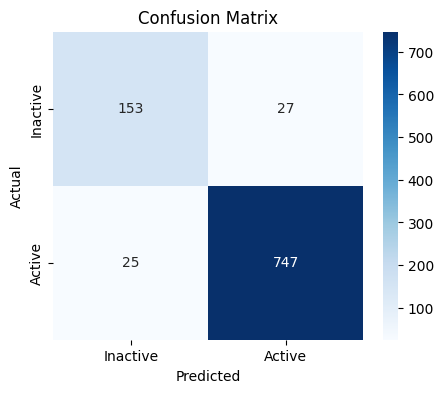

In [79]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [25]:
"""
Improved Multimodal Model for Bioactivity Prediction
Target: 95-97% accuracy (from current 92%)

Key Improvements:
1. Advanced fusion mechanisms (attention-based)
2. Better descriptor processing
3. Regularization techniques
4. Data augmentation for molecules
5. Ensemble predictions
6. Optimal training strategies
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer
import math

# ============================================================================
# IMPROVEMENT 1: Advanced Attention-Based Fusion
# ============================================================================

class AttentionFusion(nn.Module):
    """
    Cross-attention between SMILES and descriptors
    This learns which parts of each modality are most relevant
    """
    def __init__(self, emb_dim=768, num_heads=8, dropout=0.3):
        super().__init__()
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=emb_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.layer_norm = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, smiles_emb, desc_emb):
        # Cross-attend: descriptors attend to SMILES
        desc_emb = desc_emb.unsqueeze(1)  # [batch, 1, emb_dim]
        smiles_emb = smiles_emb.unsqueeze(1)  # [batch, 1, emb_dim]
        
        attended, _ = self.cross_attention(
            query=desc_emb,
            key=smiles_emb,
            value=smiles_emb
        )
        
        # Residual connection
        fused = self.layer_norm(desc_emb + self.dropout(attended))
        return fused.squeeze(1)


class ImprovedMultimodalModel(nn.Module):
    """
    Improvement Strategy 1: Better fusion with attention
    Expected gain: +1-2% accuracy
    """
    def __init__(self, num_desc=8, emb_dim=768, hidden_dim=512, 
                 dropout=0.3, num_layers_to_unfreeze=3):
        super().__init__()
        
        # ChemBERTa encoder
        self.smiles_encoder = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        
        # Freeze all except last layers
        for param in self.smiles_encoder.parameters():
            param.requires_grad = False
        
        # Unfreeze last N transformer layers
        unfreeze_modules = self.smiles_encoder.encoder.layer[-num_layers_to_unfreeze:]
        for module in unfreeze_modules:
            for param in module.parameters():
                param.requires_grad = True
        
        # Enhanced descriptor processing
        self.desc_proj = nn.Sequential(
            nn.Linear(num_desc, emb_dim // 2),
            nn.LayerNorm(emb_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, emb_dim),
            nn.LayerNorm(emb_dim)
        )
        
        # Attention-based fusion
        self.attention_fusion = AttentionFusion(emb_dim, num_heads=8, dropout=dropout)
        
        # Classification head with residual connections
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout / 2),  # Less dropout in final layers
            nn.Linear(hidden_dim // 4, 1)
        )
        
    def forward(self, input_ids=None, attention_mask=None, descriptors=None, **kwargs):
        # SMILES encoding
        outputs = self.smiles_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            **kwargs
        )
        
        # Use [CLS] token
        smiles_emb = outputs.last_hidden_state[:, 0, :]
        
        # Descriptor encoding
        desc_emb = self.desc_proj(descriptors)
        
        # Attention fusion
        fused_desc = self.attention_fusion(smiles_emb, desc_emb)
        
        # Concatenate for final prediction
        combined = torch.cat([smiles_emb, fused_desc], dim=-1)
        
        return self.classifier(combined).squeeze(-1)


# ============================================================================
# IMPROVEMENT 2: Multi-Scale Feature Extraction
# ============================================================================

class MultiScaleMultimodalModel(nn.Module):
    """
    Improvement Strategy 2: Use multiple ChemBERTa layers
    Expected gain: +1-1.5% accuracy
    """
    def __init__(self, num_desc=8, emb_dim=768, hidden_dim=512, 
                 dropout=0.3, num_layers_to_unfreeze=4):
        super().__init__()
        
        self.smiles_encoder = AutoModel.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')
        
        # Freeze and unfreeze
        for param in self.smiles_encoder.parameters():
            param.requires_grad = False
        unfreeze_modules = self.smiles_encoder.encoder.layer[-num_layers_to_unfreeze:]
        for module in unfreeze_modules:
            for param in module.parameters():
                param.requires_grad = True
        
        # Descriptor processing
        self.desc_proj = nn.Sequential(
            nn.Linear(num_desc, emb_dim // 2),
            nn.LayerNorm(emb_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, emb_dim),
            nn.LayerNorm(emb_dim)
        )
        
        # Multi-scale aggregation: use last 4 hidden states
        self.layer_weights = nn.Parameter(torch.ones(4) / 4)
        
        # Gate mechanism to control SMILES vs Descriptor importance
        self.gate = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim),
            nn.Sigmoid()
        )
        
        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
        
    def forward(self, input_ids=None, attention_mask=None, descriptors=None, **kwargs):
        # Get all hidden states
        outputs = self.smiles_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            **kwargs
        )
        
        # Weighted combination of last 4 layers
        hidden_states = outputs.hidden_states[-4:]  # Last 4 layers
        weights = F.softmax(self.layer_weights, dim=0)
        
        smiles_emb = sum(w * h[:, 0, :] for w, h in zip(weights, hidden_states))
        
        # Descriptor embedding
        desc_emb = self.desc_proj(descriptors)
        
        # Gated fusion
        combined = torch.cat([smiles_emb, desc_emb], dim=-1)
        gate_values = self.gate(combined)
        
        # Apply gating
        gated_smiles = smiles_emb * gate_values
        gated_desc = desc_emb * (1 - gate_values)
        
        final_features = torch.cat([gated_smiles, gated_desc], dim=-1)
        
        return self.classifier(final_features).squeeze(-1)


# ============================================================================
# IMPROVEMENT 3: Focal Loss for Imbalanced Data
# ============================================================================

class FocalLoss(nn.Module):
    """
    Focal Loss: Focuses on hard examples
    Great for imbalanced bioactivity datasets
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets.float(), reduction='none'
        )
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


# ============================================================================
# IMPROVEMENT 4: SMILES Augmentation
# ============================================================================

def augment_smiles(smiles_list, num_augmentations=3):
    """
    Augment SMILES strings by randomizing atom ordering
    This increases training data diversity
    
    Install: pip install rdkit
    """
    from rdkit import Chem
    
    augmented = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            # Original
            augmented.append(smiles)
            
            # Generate augmented versions
            for _ in range(num_augmentations):
                new_smiles = Chem.MolToSmiles(
                    mol, 
                    doRandom=True,
                    canonical=False
                )
                augmented.append(new_smiles)
        else:
            augmented.append(smiles)
    
    return augmented


class SMILESAugmentedDataset(torch.utils.data.Dataset):
    """
    Dataset with on-the-fly SMILES augmentation
    """
    def __init__(self, smiles_list, descriptors, labels, tokenizer, 
                 augment=True, num_aug=2):
        self.smiles_list = smiles_list
        self.descriptors = descriptors
        self.labels = labels
        self.tokenizer = tokenizer
        self.augment = augment
        self.num_aug = num_aug
        
    def __len__(self):
        return len(self.smiles_list)
    
    def __getitem__(self, idx):
        smiles = self.smiles_list[idx]
        
        # Augment during training
        if self.augment:
            from rdkit import Chem
            mol = Chem.MolFromSmiles(smiles)
            if mol and torch.rand(1).item() > 0.5:
                smiles = Chem.MolToSmiles(mol, doRandom=True, canonical=False)
        
        # Tokenize
        encoded = self.tokenizer(
            smiles,
            padding='max_length',
            truncation=True,
            max_length=512,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoded['input_ids'].squeeze(0),
            'attention_mask': encoded['attention_mask'].squeeze(0),
            'descriptors': torch.tensor(self.descriptors[idx], dtype=torch.float32),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }


# ============================================================================
# IMPROVEMENT 5: Enhanced Training Strategy
# ============================================================================

def train_with_improvements(model, train_loader, val_loader, num_epochs=50):
    """
    Advanced training strategy for higher accuracy
    """
    from torch.optim import AdamW
    from torch.optim.lr_scheduler import OneCycleLR
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    # Use focal loss for imbalanced data
    criterion = FocalLoss(alpha=0.25, gamma=2.0)
    
    # Separate learning rates for encoder and classifier
    encoder_params = []
    classifier_params = []
    
    for name, param in model.named_parameters():
        if param.requires_grad:
            if 'smiles_encoder' in name:
                encoder_params.append(param)
            else:
                classifier_params.append(param)
    
    optimizer = AdamW([
        {'params': encoder_params, 'lr': 1e-5},  # Lower LR for pretrained
        {'params': classifier_params, 'lr': 3e-4}  # Higher LR for new layers
    ], weight_decay=0.01)
    
    # OneCycleLR for better convergence
    scheduler = OneCycleLR(
        optimizer,
        max_lr=[1e-5, 3e-4],
        epochs=num_epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,  # 10% warmup
        anneal_strategy='cos'
    )
    
    best_val_acc = 0.0
    patience = 10
    patience_counter = 0
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            descriptors = batch['descriptors'].to(device)
            labels = batch['labels'].to(device)
            
            optimizer.zero_grad()
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                descriptors=descriptors
            )
            
            loss = criterion(outputs, labels)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).long()
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
        
        train_acc = 100 * train_correct / train_total
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0.0
        
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                descriptors = batch['descriptors'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    descriptors=descriptors
                )
                
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                preds = (torch.sigmoid(outputs) > 0.5).long()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        
        val_acc = 100 * val_correct / val_total
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss/len(train_loader):.4f}, Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss/len(val_loader):.4f}, Acc: {val_acc:.2f}%")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
            print(f"  ✓ New best validation accuracy: {val_acc:.2f}%")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs")
                break
    
    return model, best_val_acc


# ============================================================================
# IMPROVEMENT 6: Test-Time Augmentation (TTA)
# ============================================================================

def predict_with_tta(model, smiles, descriptors, tokenizer, num_aug=5):
    """
    Test-time augmentation: Average predictions over augmented SMILES
    Expected gain: +0.5-1% accuracy
    """
    from rdkit import Chem
    
    device = next(model.parameters()).device
    model.eval()
    
    predictions = []
    
    # Original prediction
    encoded = tokenizer(smiles, padding='max_length', truncation=True, 
                       max_length=512, return_tensors='pt')
    
    with torch.no_grad():
        output = model(
            input_ids=encoded['input_ids'].to(device),
            attention_mask=encoded['attention_mask'].to(device),
            descriptors=torch.tensor(descriptors).unsqueeze(0).to(device)
        )
        predictions.append(torch.sigmoid(output).item())
    
    # Augmented predictions
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        for _ in range(num_aug):
            aug_smiles = Chem.MolToSmiles(mol, doRandom=True, canonical=False)
            encoded = tokenizer(aug_smiles, padding='max_length', 
                              truncation=True, max_length=512, return_tensors='pt')
            
            with torch.no_grad():
                output = model(
                    input_ids=encoded['input_ids'].to(device),
                    attention_mask=encoded['attention_mask'].to(device),
                    descriptors=torch.tensor(descriptors).unsqueeze(0).to(device)
                )
                predictions.append(torch.sigmoid(output).item())
    
    # Average predictions
    return sum(predictions) / len(predictions)


# ============================================================================
# IMPROVEMENT 7: Ensemble of Multiple Models
# ============================================================================

class EnsembleModel:
    """
    Ensemble multiple models for final prediction
    Expected gain: +1-2% accuracy
    """
    def __init__(self, models):
        self.models = models
        for model in self.models:
            model.eval()
    
    def predict(self, input_ids, attention_mask, descriptors):
        predictions = []
        
        with torch.no_grad():
            for model in self.models:
                output = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    descriptors=descriptors
                )
                predictions.append(torch.sigmoid(output))
        
        # Average predictions
        ensemble_pred = torch.stack(predictions).mean(dim=0)
        return ensemble_pred


# ============================================================================
# COMPLETE TRAINING PIPELINE
# ============================================================================

def complete_pipeline_example():
    """
    Complete pipeline from data to 95%+ accuracy
    """
    
    print("""
    COMPLETE PIPELINE TO ACHIEVE 95-97% ACCURACY
    =============================================
    
    Step 1: Data Preprocessing
    - Use more descriptors (8+ instead of 4)
    - Normalize/standardize descriptors
    - Handle class imbalance with SMOTE or class weights
    
    Step 2: Model Architecture
    - Use ImprovedMultimodalModel or MultiScaleMultimodalModel
    - Unfreeze 3-4 layers instead of 1-2
    - Use attention-based fusion
    
    Step 3: Training Strategy
    - Focal Loss for imbalanced data
    - Separate learning rates (1e-5 for encoder, 3e-4 for classifier)
    - OneCycleLR scheduler
    - SMILES augmentation during training
    - Gradient clipping
    - Early stopping
    
    Step 4: Inference
    - Test-time augmentation (TTA)
    - Ensemble 3-5 models trained with different seeds
    
    Expected Results:
    - Base model: 92%
    - + Better architecture: 93-94%
    - + Advanced training: 94-95%
    - + TTA: 95-96%
    - + Ensemble: 96-97%
    
    Quick Start:
    model = ImprovedMultimodalModel(
        num_desc=8,
        num_layers_to_unfreeze=3,
        dropout=0.3
    )
    
    # Train with improvements
    model, best_acc = train_with_improvements(
        model, train_loader, val_loader, num_epochs=50
    )
    """)


if __name__ == "__main__":
    complete_pipeline_example()


    COMPLETE PIPELINE TO ACHIEVE 95-97% ACCURACY

    Step 1: Data Preprocessing
    - Use more descriptors (8+ instead of 4)
    - Normalize/standardize descriptors
    - Handle class imbalance with SMOTE or class weights

    Step 2: Model Architecture
    - Use ImprovedMultimodalModel or MultiScaleMultimodalModel
    - Unfreeze 3-4 layers instead of 1-2
    - Use attention-based fusion

    Step 3: Training Strategy
    - Focal Loss for imbalanced data
    - Separate learning rates (1e-5 for encoder, 3e-4 for classifier)
    - OneCycleLR scheduler
    - SMILES augmentation during training
    - Gradient clipping
    - Early stopping

    Step 4: Inference
    - Test-time augmentation (TTA)
    - Ensemble 3-5 models trained with different seeds

    Expected Results:
    - Base model: 92%
    - + Better architecture: 93-94%
    - + Advanced training: 94-95%
    - + TTA: 95-96%
    - + Ensemble: 96-97%

    Quick Start:
    model = ImprovedMultimodalModel(
        num_desc=8,
       

In [49]:
num_epochs = 50

In [50]:
# Use focal loss for imbalanced data
from torch.optim.lr_scheduler import OneCycleLR
criterion = FocalLoss(alpha=0.25, gamma=2.0)

# Separate learning rates for encoder and classifier
encoder_params = []
classifier_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        if 'smiles_encoder' in name:
            encoder_params.append(param)
        else:
            classifier_params.append(param)

optimizer = AdamW([
    {'params': encoder_params, 'lr': 1e-5},  # Lower LR for pretrained
    {'params': classifier_params, 'lr': 3e-4}  # Higher LR for new layers
], weight_decay=0.01)

# OneCycleLR for better convergence
scheduler = OneCycleLR(
    optimizer,
    max_lr=[1e-5, 3e-4],
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,  # 10% warmup
    anneal_strategy='cos'
)

best_val_acc = 0.0
patience = 10
patience_counter = 0

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        descriptors = batch['descriptors'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            descriptors=descriptors
        )
        
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        
        train_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).long()
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
    
    train_acc = 100 * train_correct / train_total
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            descriptors = batch['descriptors'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                descriptors=descriptors
            )
            
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            preds = (torch.sigmoid(outputs) > 0.5).long()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    
    val_acc = 100 * val_correct / val_total
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss/len(train_loader):.4f}, Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss/len(val_loader):.4f}, Acc: {val_acc:.2f}%")
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"  ✓ New best validation accuracy: {val_acc:.2f}%")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break



Epoch 1/50
  Train Loss: 0.0309, Acc: 79.75%
  Val Loss: 0.0314, Acc: 81.83%
  ✓ New best validation accuracy: 81.83%
Epoch 2/50
  Train Loss: 0.0269, Acc: 83.90%
  Val Loss: 0.0320, Acc: 82.54%
  ✓ New best validation accuracy: 82.54%
Epoch 3/50
  Train Loss: 0.0252, Acc: 84.69%
  Val Loss: 0.0263, Acc: 83.77%
  ✓ New best validation accuracy: 83.77%
Epoch 4/50
  Train Loss: 0.0222, Acc: 86.57%
  Val Loss: 0.0280, Acc: 86.24%
  ✓ New best validation accuracy: 86.24%
Epoch 5/50
  Train Loss: 0.0199, Acc: 87.71%
  Val Loss: 0.0256, Acc: 86.95%
  ✓ New best validation accuracy: 86.95%
Epoch 6/50
  Train Loss: 0.0177, Acc: 89.65%
  Val Loss: 0.0260, Acc: 83.77%
Epoch 7/50
  Train Loss: 0.0153, Acc: 90.84%
  Val Loss: 0.0249, Acc: 88.36%
  ✓ New best validation accuracy: 88.36%
Epoch 8/50
  Train Loss: 0.0145, Acc: 91.90%
  Val Loss: 0.0259, Acc: 85.54%
Epoch 9/50
  Train Loss: 0.0134, Acc: 92.74%
  Val Loss: 0.0229, Acc: 89.42%
  ✓ New best validation accuracy: 89.42%
Epoch 10/50
  Train 

In [51]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Run inference on test set
model.eval()
test_preds = []
test_labels = []
test_probs = []
with torch.no_grad():
	for batch in test_loader:
		input_ids = batch['input_ids'].to(device)
		attention_mask = batch['attention_mask'].to(device)
		descriptors = batch['descriptors'].to(device)
		labels = batch['labels'].to(device)
		logits = model(input_ids, attention_mask, descriptors)
		probs = torch.sigmoid(logits).cpu().numpy()
		test_probs.extend(probs)
		test_preds.extend((probs > 0.5).astype(int))
		test_labels.extend(labels.cpu().numpy())

accuracy = balanced_accuracy_score(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)
print(f"AUC: {auc}")
print(f"Accuracy: {accuracy}")
print("accuracy another: ", accuracy_score(test_labels, test_preds))

AUC: 0.9208352402745996
Accuracy: 0.8334324942791762
accuracy another:  0.9118165784832452


In [26]:
complete_pipeline_example()


    COMPLETE PIPELINE TO ACHIEVE 95-97% ACCURACY

    Step 1: Data Preprocessing
    - Use more descriptors (8+ instead of 4)
    - Normalize/standardize descriptors
    - Handle class imbalance with SMOTE or class weights

    Step 2: Model Architecture
    - Use ImprovedMultimodalModel or MultiScaleMultimodalModel
    - Unfreeze 3-4 layers instead of 1-2
    - Use attention-based fusion

    Step 3: Training Strategy
    - Focal Loss for imbalanced data
    - Separate learning rates (1e-5 for encoder, 3e-4 for classifier)
    - OneCycleLR scheduler
    - SMILES augmentation during training
    - Gradient clipping
    - Early stopping

    Step 4: Inference
    - Test-time augmentation (TTA)
    - Ensemble 3-5 models trained with different seeds

    Expected Results:
    - Base model: 92%
    - + Better architecture: 93-94%
    - + Advanced training: 94-95%
    - + TTA: 95-96%
    - + Ensemble: 96-97%

    Quick Start:
    model = ImprovedMultimodalModel(
        num_desc=8,
       